In [203]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  
import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
df['job_type_skills'] = df['job_type_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else {})

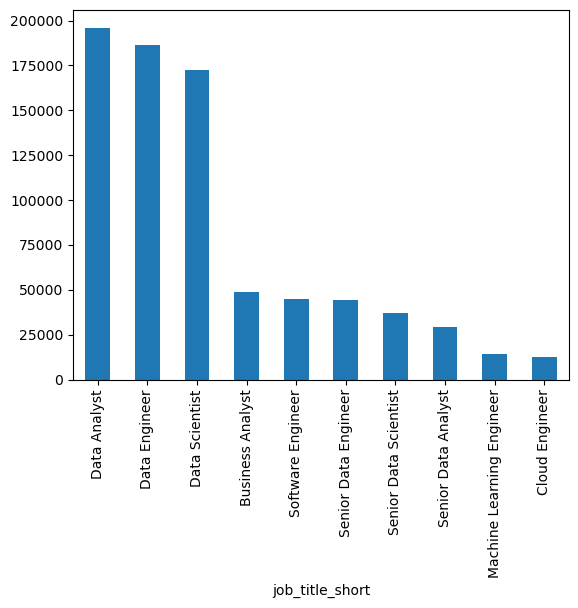

In [2]:
fig, ax = plt.subplots()

df["job_title_short"].value_counts().plot(kind='bar', ax=ax)
plt.show()

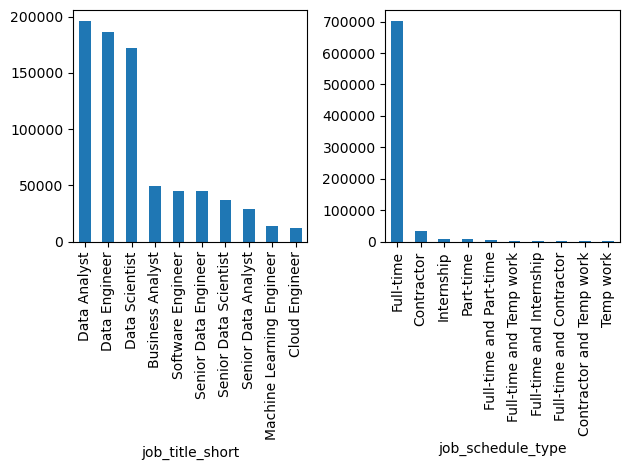

In [3]:
# Method 1: Using subplots to create multiple plots in one figure
fig, ax = plt.subplots(1,2)

df["job_title_short"].value_counts().plot(kind='bar', ax=ax[0])
df["job_schedule_type"].value_counts().head(10).plot(kind='bar', ax=ax[1])
plt.tight_layout()
plt.show()

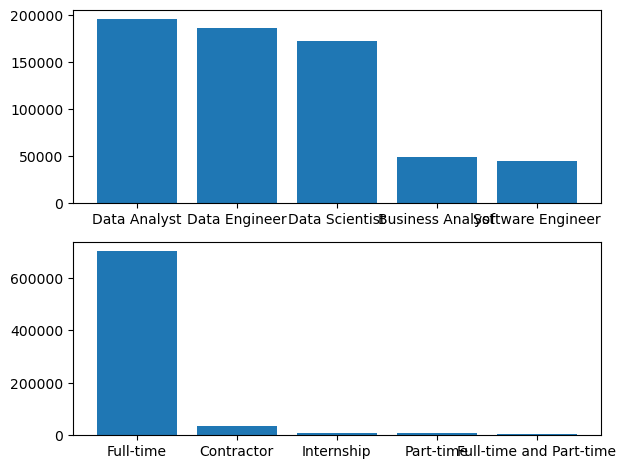

In [4]:
# Method 2
fig, ax = plt.subplots(2,1)

ax[0].bar(df["job_title_short"].value_counts().head(5).index, df["job_title_short"].value_counts().head(5))
ax[1].bar(df["job_schedule_type"].value_counts().head(5).index, df["job_schedule_type"].value_counts().head(5))
plt.tight_layout()
plt.show()

In [5]:
df_skills = df.copy()

df_skills = df_skills.explode('job_skills')
skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count = skills_count.reset_index(name='skill_count')
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)
df_skills_count

,job_skills,job_title_short,skill_count
1480,python,Data Scientist,113711
1822,sql,Data Engineer,113130
1479,python,Data Engineer,108022
1821,sql,Data Analyst,92428
1823,sql,Data Scientist,78982
...,...,...,...
2173,webex,Senior Data Scientist,1
1054,mattermost,Data Scientist,1
270,clickup,Machine Learning Engineer,1
797,heroku,Senior Data Analyst,1


In [6]:
# Top 3 job titles
top_job_titles = df["job_title_short"].value_counts().sort_values(ascending=False).head(3).index.tolist()
top_job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

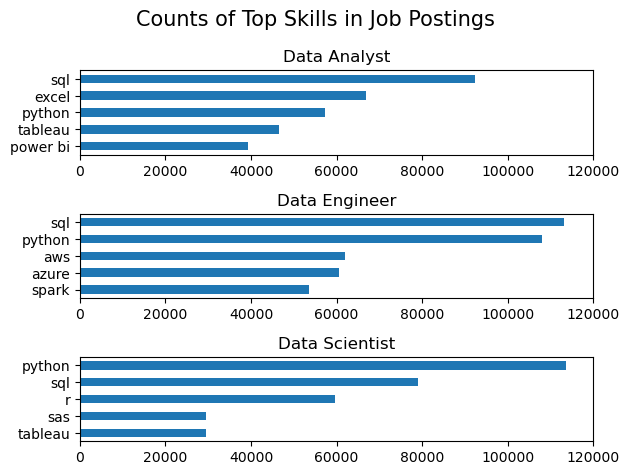

In [11]:
fig, ax = plt.subplots(len(top_job_titles),1)
for i, job_title in enumerate(top_job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title=job_title)
    ax[i].set_ylabel("")
    ax[i].invert_yaxis()  # Invert y-axis to have the highest count on top
    ax[i].legend().remove()  # Remove legend for clarity
    ax[i].set_xlim(0, 120000) # Set x-axis limits to focus on the range of interest
fig.suptitle('Counts of Top Skills in Job Postings', fontsize=15)
plt.tight_layout()
plt.show()


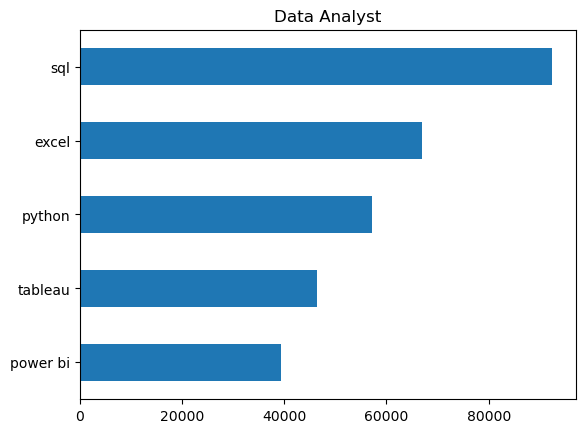

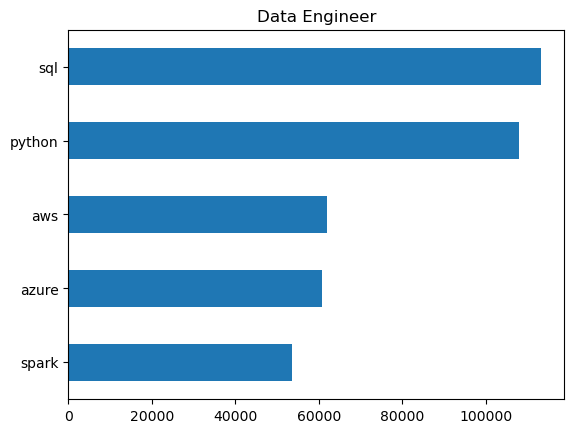

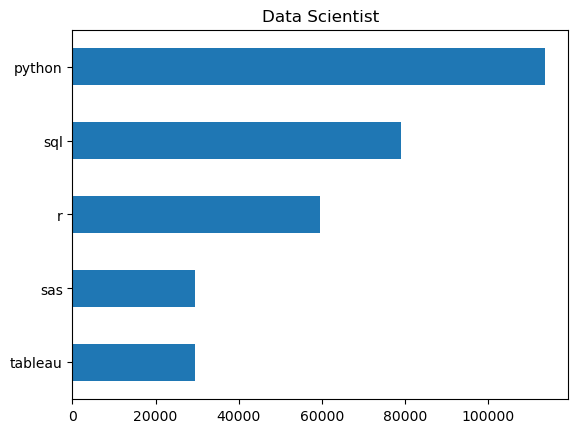

In [12]:
for i, job_title in enumerate(top_job_titles):
    df_skills_count[df_skills_count['job_title_short'] == job_title].head(5).plot(kind='barh', x='job_skills', y='skill_count', title=job_title)
    plt.gca().invert_yaxis()
    plt.gca().set_ylabel('')
    plt.gca().get_legend().remove()
    plt.show()

In [15]:
work_from_home = df["job_work_from_home"].value_counts()
job_no_degree = df["job_no_degree_mention"].value_counts()
job_health_insurance = df["job_health_insurance"].value_counts()

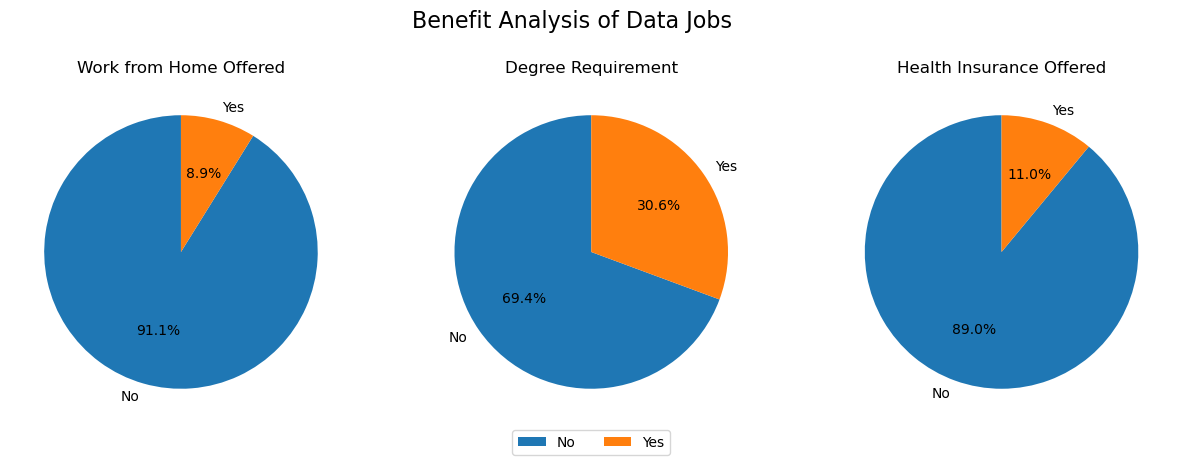

In [109]:
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1,3, figsize=(15,5))

for i, [column, title] in enumerate(dict_column.items()):
    ax[i].pie(df[column].value_counts(), labels=['No', 'Yes'], autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)

plt.suptitle('Benefit Analysis of Data Jobs', fontsize=16)
plt.legend(loc='upper center', bbox_to_anchor=(-0.70, 0), ncol=2)
#plt.tight_layout()
plt.show()


In [38]:
df_da = df[df['job_title_short'] == 'Data Analyst'].copy()

df_exploded = df_da.explode('job_skills')
skills_stats = df_exploded.groupby('job_skills').agg(
    median_salary=('salary_year_avg', 'median'),
    skill_count=('job_skills', 'count')
)
skills_stats = skills_stats.sort_values(by='skill_count', ascending=False).head(10)
skills_stats.head(10)

,median_salary,skill_count
job_skills,,
sql,92500.0,92428
excel,84479.0,66860
python,98500.0,57190
tableau,95000.0,46455
power bi,90000.0,39380
r,92527.5,29996
sas,90000.0,27998
powerpoint,85000.0,13822
word,80000.0,13562


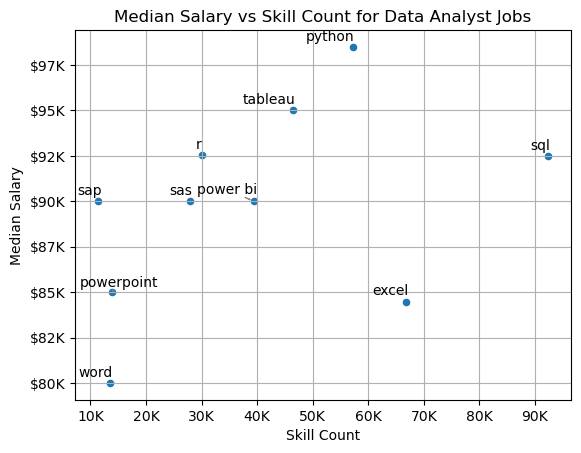

In [94]:
from adjustText import adjust_text
skills_stats.plot(kind='scatter', x='skill_count', y='median_salary')

# Prepare texts for adjustText
texts = []
for i,txt in enumerate(skills_stats.index):
    texts.append(plt.text(skills_stats['skill_count'].iloc[i], skills_stats['median_salary'].iloc[i], txt, fontsize=10, ha='right', va='bottom'))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Get current axes, set limits, and format axes
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x/1000)}K'))  # Format x-axis as integers

plt.title('Median Salary vs Skill Count for Data Analyst Jobs')
plt.xlabel('Skill Count')
plt.ylabel('Median Salary')
plt.grid(True)
plt.show()

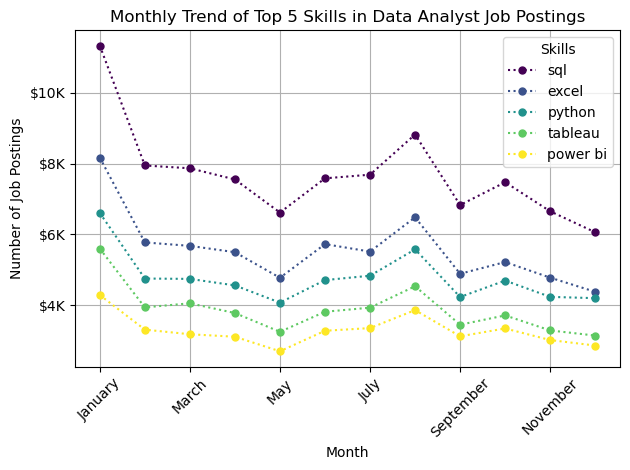

In [110]:
df_data_analyst = df[df['job_title_short'] == 'Data Analyst'].copy()
df_data_analyst["month_number"] = df_data_analyst['job_posted_date'].dt.month

df_data_analyst = df_data_analyst.explode('job_skills')

df_data_analyst_pivot = df_data_analyst.pivot_table(index='month_number', columns='job_skills', aggfunc='size', fill_value=0)
df_data_analyst_pivot.loc['Total'] = df_data_analyst_pivot.sum()
df_data_analyst_pivot = df_data_analyst_pivot[df_data_analyst_pivot.loc['Total'].sort_values(ascending=False).index]
df_data_analyst_pivot.drop('Total', inplace=True)

# use month name for plotting
df_data_analyst_pivot = df_data_analyst_pivot.reset_index()
df_data_analyst_pivot['job_posted_month'] = df_data_analyst_pivot['month_number'].apply(lambda x: pd.to_datetime(str(x), format='%m').strftime('%B'))
df_data_analyst_pivot = df_data_analyst_pivot.set_index('job_posted_month').drop('month_number', axis=1)

#get top 5 skills for plotting
df_data_analyst_pivot = df_data_analyst_pivot.iloc[:, :5]
df_data_analyst_pivot.plot(
    kind='line',
    linestyle=':', # options: '-', '--', '-.', ':'
    colormap='viridis', # options: 'viridis', 'plasma', 'inferno', 'magma', 'cividis' 
    markersize=5,
    marker='o', # options: 'o', 'x', '+', '*', 's', ',', '.', '1', '2', '3', '4', ...
)

# Get current axes, set limits, and format axes
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

plt.title('Monthly Trend of Top 5 Skills in Data Analyst Job Postings')
plt.xlabel('Month')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Skills')
plt.tight_layout()
plt.show()

In [115]:
df_da_usa = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

df_da_usa = df_da_usa.dropna(subset='salary_year_avg')

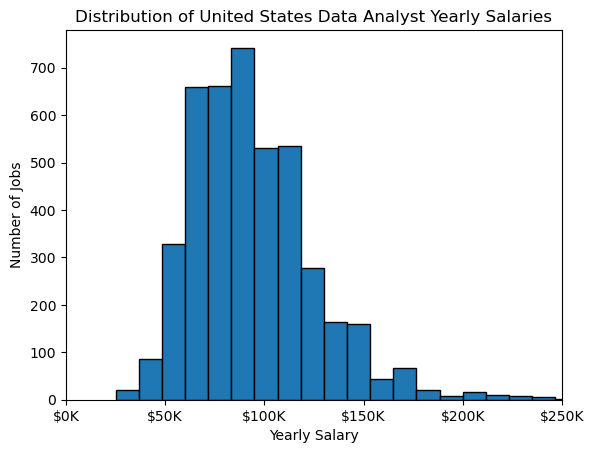

In [120]:
df_da_usa['salary_year_avg'].plot(kind='hist', bins=30, edgecolor='black')

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

plt.xlim(0,250000)
plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary')
plt.ylabel('Number of Jobs')
plt.show()



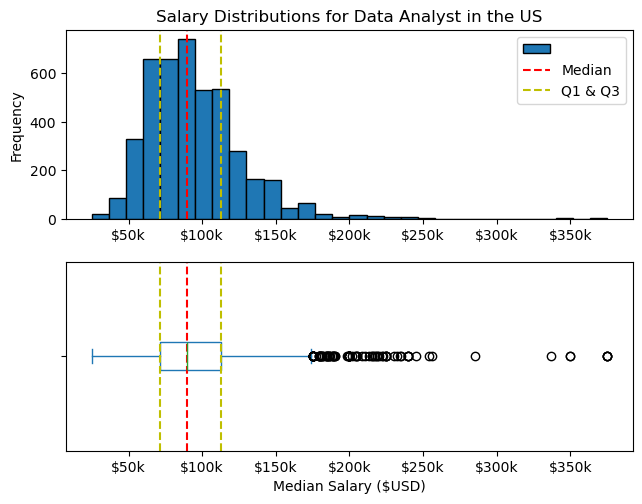

In [146]:
fig, ax = plt.subplots(2,1)
fig.tight_layout(h_pad=1)
df_da_usa['salary_year_avg'].plot(kind='hist', ax=ax[0], edgecolor='black', bins=30)
ax[0].set_title("Salary Distributions for Data Analyst in the US")
ax[0].set_xlabel('')
ax[0].set_ylabel('Frequency')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: '${0:g}k'.format(x/1000)))
# Lines
ax[0].axvline(df_da_usa['salary_year_avg'].median(), color='r', linestyle='--')
ax[0].axvline(df_da_usa['salary_year_avg'].quantile(0.25), color='y', linestyle='--')
ax[0].axvline(df_da_usa['salary_year_avg'].quantile(0.75), color='y', linestyle='--')
ax[0].legend(['', 'Median', 'Q1 & Q3'])

df_da_usa['salary_year_avg'].plot(kind='box', vert=False, ax=ax[1])
ax[1].set_yticklabels('')
ax[1].set_xlabel('Median Salary ($USD)')
ax[1].set_ylabel('')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: '${0:g}k'.format(x/1000)))
# lines
ax[1].axvline(df_da_usa['salary_year_avg'].median(), color='r', linestyle='--')
ax[1].axvline(df_da_usa['salary_year_avg'].quantile(0.25), color='y', linestyle='--')
ax[1].axvline(df_da_usa['salary_year_avg'].quantile(0.75), color='y', linestyle='--')
plt.show()

/var/folders/n9/5bzcp8yn60sfkd70xv35_4vm0000gn/T/ipykernel_95899/1579268782.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(salaries, labels=job_titles, vert=False)


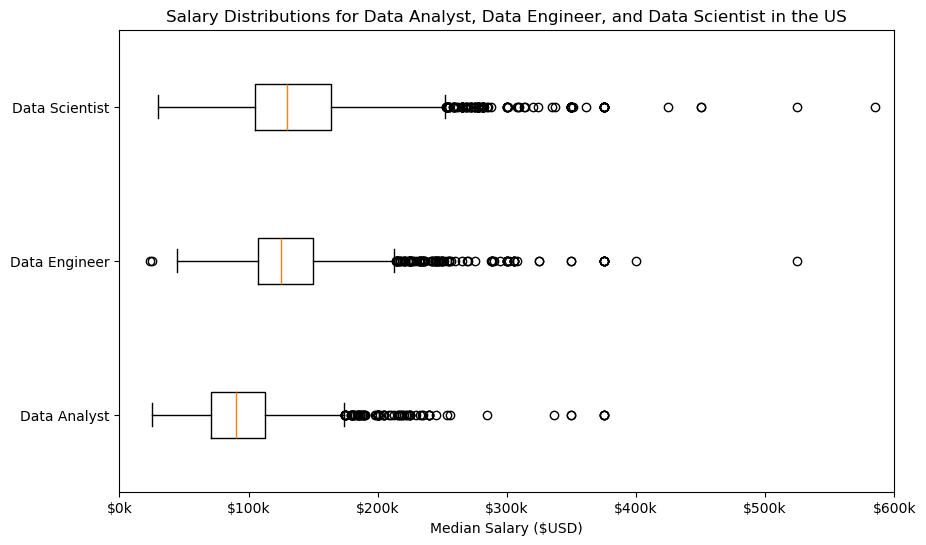

In [166]:
# Top 3 job titles
job_titles = df['job_title_short'].value_counts().head(3).index.tolist()

# filter for the job titles and country
df_title_country = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].dropna(subset=['salary_year_avg'])

# list of salaries for each job title
salaries = [df_title_country[df_title_country['job_title_short'] == title]['salary_year_avg'] for title in job_titles]

# Create box plot
plt.figure(figsize=(10,6))
plt.boxplot(salaries, labels=job_titles, vert=False)
plt.title('Salary Distributions for Data Analyst, Data Engineer, and Data Scientist in the US')
plt.xlabel('Median Salary ($USD)')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: '${0:g}k'.format(x/1000)))
plt.xlim(0, 600000)
plt.show()

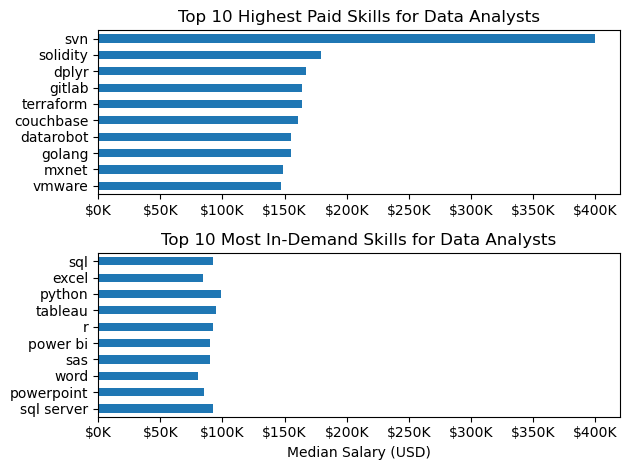

In [205]:
#df_data_analyst

# Get the highest paying skills (order by highest to lowest).
df_top_pay = df_data_analyst.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='median', ascending=False).head(10)

# Match up the highest count (demand) of skills and highest median salary by skill for data analyst roles.
df_top_skills = df_data_analyst.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count', ascending=False).head(10)

fig, ax = plt.subplots(2,1)

# Top 10 Highest Paid Skills for Data Analysts
df_top_pay[::-1].plot(
    kind='barh', 
    ax=ax[0], 
    y='median', 
    legend=False
) 
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))


# Top 10 Most In-Demand Skills for Data Analysts
df_top_skills[::-1].plot(
    kind='barh', 
    y='median', 
    ax=ax[1], 
    legend=False
)
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())  # Set the same x-axis limits as the first plot
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.tight_layout()
plt.show()


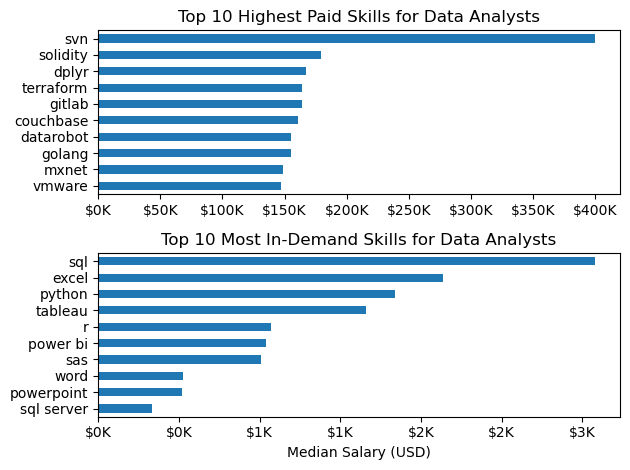

In [200]:
# Formated code using chatgpt
# Top 10 Highest Paid Skills
df_top_pay = (
    df_data_analyst
    .explode('job_skills')  # IMPORTANT if not already done
    .groupby('job_skills')['salary_year_avg']
    .agg(['count','median'])
    .sort_values(by='median', ascending=False)
    .head(10)
)

# Top 10 Most In-Demand Skills
df_top_skills = (
    df_data_analyst
    .explode('job_skills')
    .groupby('job_skills')['salary_year_avg']
    .agg(['count','median'])
    .sort_values(by='count', ascending=False)
    .head(10)
)

fig, ax = plt.subplots(2,1)

# Highest Paid
df_top_pay.sort_values(by='median', ascending=True).plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
ax[0].set_ylabel('')
ax[0].set_xlabel('')

# Most In-Demand
df_top_skills.sort_values(by='count', ascending=True).plot(kind='barh', y='count', ax=ax[1], legend=False)
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')

plt.tight_layout()
plt.show()

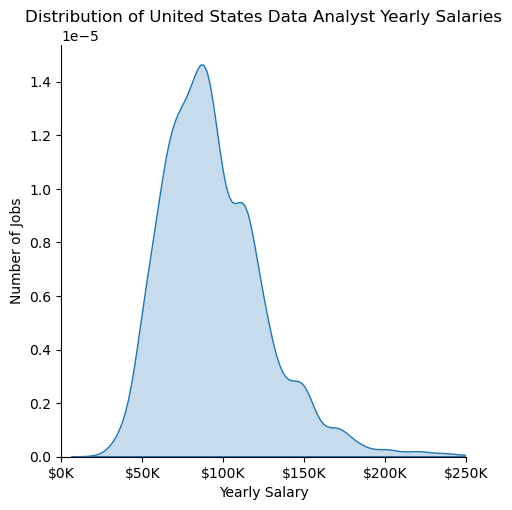

In [204]:
#df_da_usa['salary_year_avg'].plot(kind='hist', bins=30, edgecolor='black')
sns.displot(df_da_usa['salary_year_avg'], kind='kde', fill=True, common_norm=False)

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

plt.xlim(0,250000)
plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary')
plt.ylabel('Number of Jobs')
plt.show()

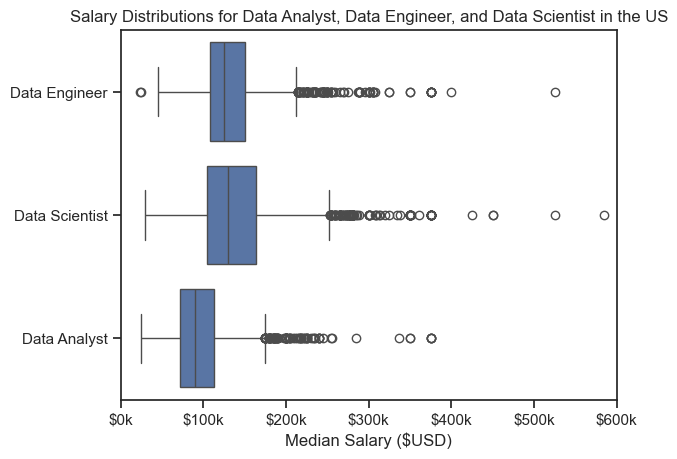

In [215]:
# Top 3 job titles
job_titles = df['job_title_short'].value_counts().head(3).index.tolist()

# filter for the job titles and country
df_title_country = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].dropna(subset=['salary_year_avg'])

# Create box plot
sns.boxplot(data=df_title_country, x='salary_year_avg', y='job_title_short')
sns.set_theme(style='ticks')
plt.title('Salary Distributions for Data Analyst, Data Engineer, and Data Scientist in the US')
plt.xlabel('Median Salary ($USD)')
plt.ylabel('')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: '${0:g}k'.format(x/1000)))
plt.xlim(0, 600000)
plt.show()

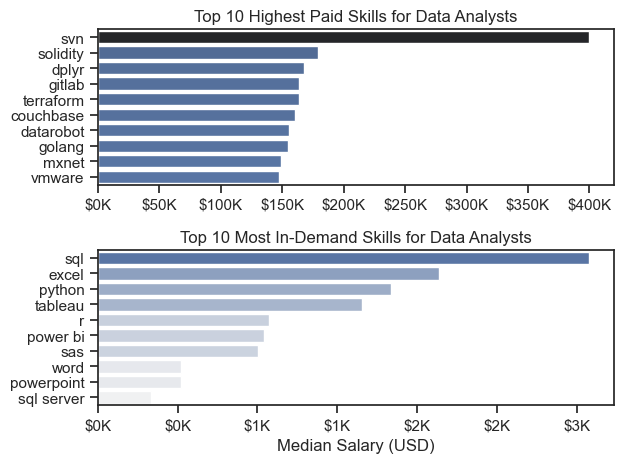

In [223]:
# Top 10 Highest Paid Skills
df_top_pay = (
    df_data_analyst
    .explode('job_skills')  # IMPORTANT if not already done
    .groupby('job_skills')['salary_year_avg']
    .agg(['count','median'])
    .sort_values(by='median', ascending=False)
    .head(10)
)

# Top 10 Most In-Demand Skills
df_top_skills = (
    df_data_analyst
    .explode('job_skills')
    .groupby('job_skills')['salary_year_avg']
    .agg(['count','median'])
    .sort_values(by='count', ascending=False)
    .head(10)
)

fig, ax = plt.subplots(2,1)

sns.set_theme(style='ticks')

# Highest Paid
sns.barplot(data=df_top_pay, x='median', y=df_top_pay.index, hue='median', ax=ax[0], palette='dark:b_r')
ax[0].legend().remove()
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
ax[0].set_ylabel('')
ax[0].set_xlabel('')

# Most In-Demand
sns.barplot(data=df_top_skills, x='count', y=df_top_skills.index, hue='count', ax=ax[1], palette='light:b')
ax[1].legend().remove()
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')

plt.tight_layout()
plt.show()